<a href="https://colab.research.google.com/github/antoinewrd1/Buy-Now-Pay-Later-Credit-Risk-Modeling-and-Customer-Analytics/blob/main/Buy_Now_Pay_Later_(BNPL)_Credit_Risk_Monitor_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Antoine Ward

**Date:** 4/29/26

# **Introduction**

Buy Now, Pay Later (BNPL) services have rapidly grown in popularity by offering consumers flexible, short-term financing with minimal barriers. However, this convenience introduces increased credit risk for providers, making accurate default prediction essential for sustainable operations.

This report applies a data-driven approach to analyze and predict credit risk using a BNPL dataset. It involves data preprocessing, exploratory analysis, and the development of machine learning models for both risk score prediction and default classification. Model performance is evaluated and optimized using standard metrics and validation techniques.

Additionally, clustering and anomaly detection methods are used to uncover customer segments and identify unusual risk patterns. Overall, the project demonstrates how machine learning can support effective credit risk assessment and decision-making in the BNPL industry.

# **Install & Load Packages**

This section ensures all required libraries are available and loaded.

It defines a list of packages (for data manipulation, modeling, visualization, etc.). Checks which are already installed. Installs missing ones automatically. Loads them into the session.

Purpose: Set up the environment so all tools needed for data science (EDA, ML models, clustering, etc.) are ready.

In [ ]:
## ========================================================================
## 1. Install & Load Packages
## ========================================================================
packages <- c("tidyverse","caret","glmnet","randomForest","e1071",
              "rpart","dbscan","isotree","factoextra","nnet","pROC",
              "reshape2","kernlab")

installed <- rownames(installed.packages())
for (p in packages) {
  if (!(p %in% installed)) install.packages(p)
}

library(tidyverse)
library(caret)
library(glmnet)
library(randomForest)
library(e1071)
library(rpart)
library(dbscan)
library(isotree)
library(factoextra)
library(nnet)
library(pROC)
library(reshape2)
library(kernlab)

# **Load Data**

Downloads the dataset from Kaggle using a system command.
Reads the CSV into a dataframe.

Purpose:
Bring the Buy Now Pay Later (BNPL) dataset into R for analysis.

In [ ]:
## ========================================================================
## 2. Load Data
## ========================================================================

system("kaggle datasets download -d shree0910/buy-now-and-pay-later-fintech-ml-dataset -p data --unzip")
df <- read.csv("data/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

# **Data Preparation**

This is feature engineering and cleaning.

Key steps:

Convert categorical variables into factors.
Convert transaction_date into Date format.
Create a new feature:
days_since_transaction = current date - transaction date
Remove the original date column.
Standardize the target variable (default_flag) into:
"default"
"no_default"

Purpose:
Prepare clean, consistent, and model-ready data.

In [ ]:
## ========================================================================
## 3. Data Preparation
## ========================================================================
df <- df %>%
  mutate(
    employment_type = as.factor(employment_type),
    product_category = as.factor(product_category),
    location = as.factor(location),
    customer_segment = as.factor(customer_segment),
    default_flag = as.factor(default_flag),
    transaction_date = as.Date(transaction_date),
    days_since_transaction = as.numeric(Sys.Date() - transaction_date)
  ) %>%
  select(-transaction_date)

df$default_flag <- as.character(df$default_flag)
df$default_flag <- ifelse(df$default_flag %in% c("1","yes","Y","true","TRUE",1),
                          "default", "no_default")
df$default_flag <- factor(df$default_flag, levels = c("default","no_default"))

# **Exploratory Data Analysis (EDA)**

Provides data visualizations to identify patterns and relationships:

a. Risk Score Distribution
Histogram of risk_score.

Helps understand distribution (normal, skewed, etc.)

b. Default Rate by Segment
Bar chart (proportional).

Shows which customer segments default more.

c. Income vs Risk
Scatter plot of income vs risk score.

Identifies correlation between income and risk.

d. Correlation Heatmap
Computes correlations between numeric variables.
Visualizes using a heatmap.

Detects multicollinearity and strong relationships.

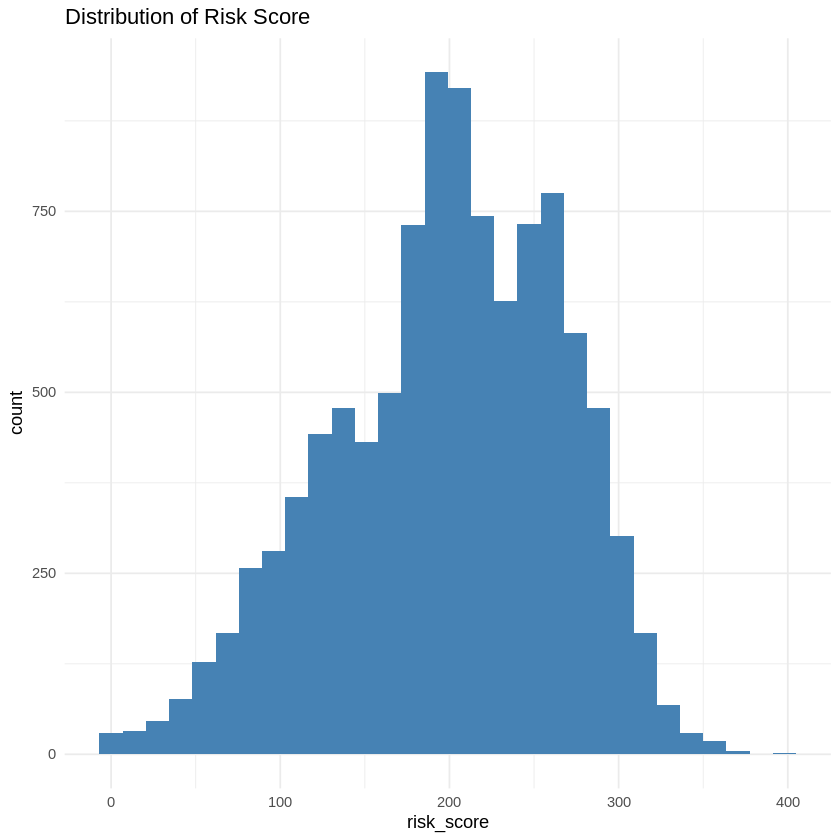

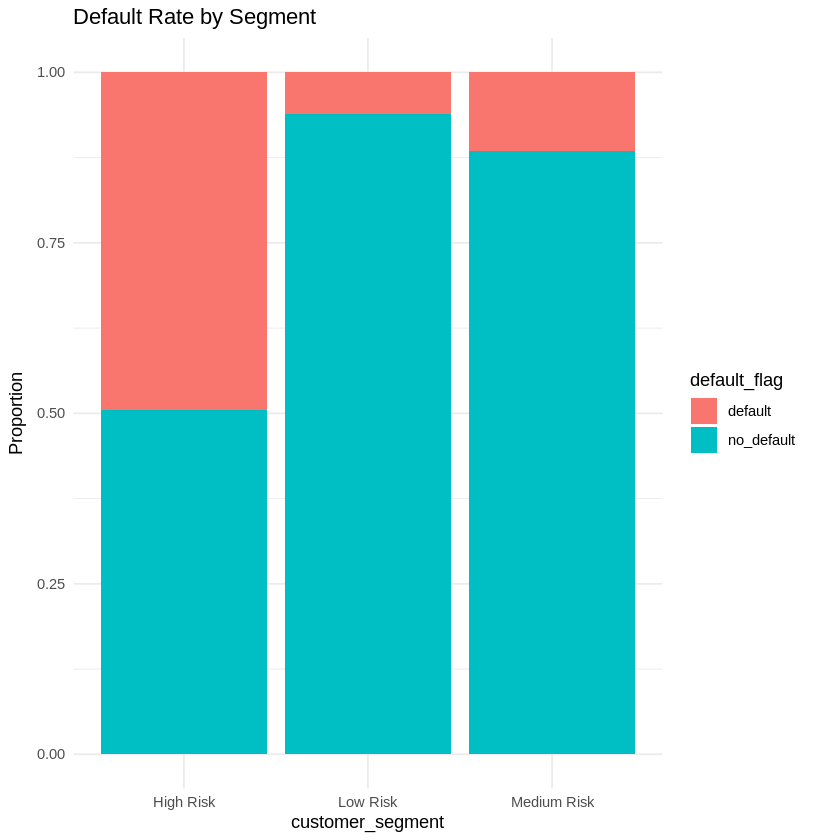

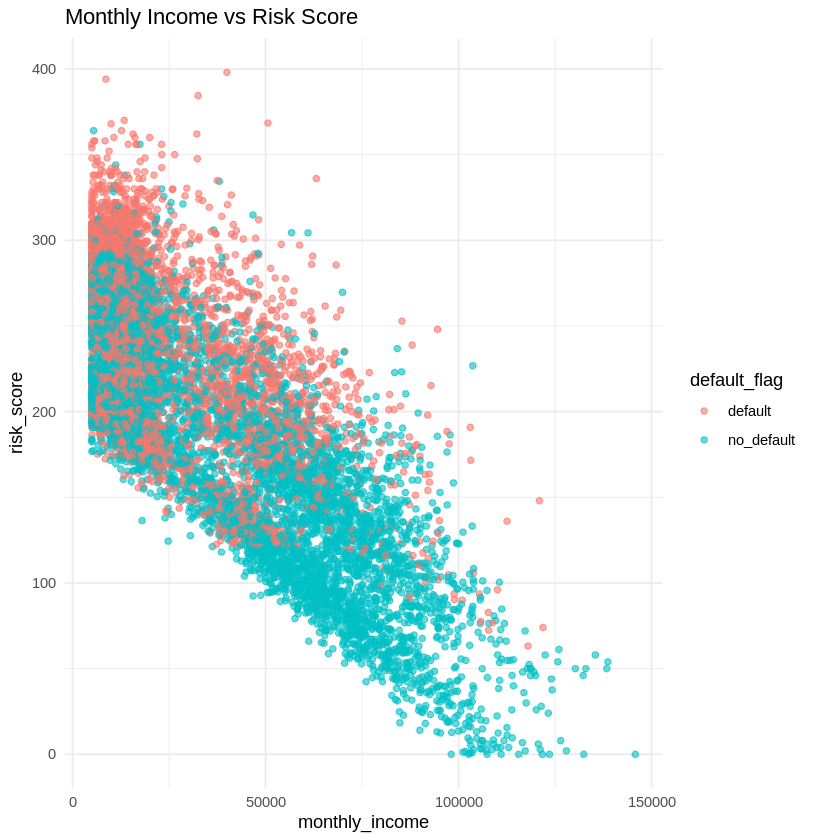

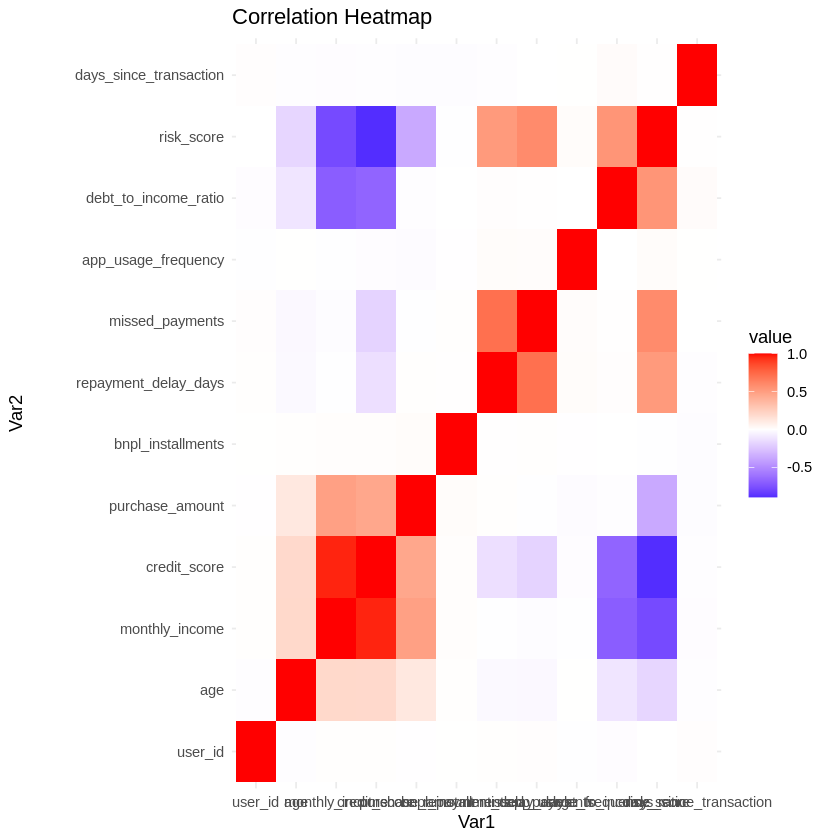

In [ ]:
## ========================================================================
## 4. Exploratory Data Analysis (EDA)
## ========================================================================

# Risk Score Distribution
ggplot(df, aes(x = risk_score)) +
  geom_histogram(bins = 30, fill = "steelblue") +
  theme_minimal() +
  labs(title = "Distribution of Risk Score")

# Default Rate by Segment
ggplot(df, aes(x = customer_segment, fill = default_flag)) +
  geom_bar(position = "fill") +
  theme_minimal() +
  labs(title = "Default Rate by Segment", y = "Proportion")

# Income vs Risk
ggplot(df, aes(x = monthly_income, y = risk_score, color = default_flag)) +
  geom_point(alpha = 0.6) +
  theme_minimal() +
  labs(title = "Monthly Income vs Risk Score")

# Correlation Heatmap
num_df <- df %>% select(where(is.numeric))
corr_matrix <- cor(num_df, use = "complete.obs")
melted_corr <- melt(corr_matrix)

ggplot(melted_corr, aes(Var1, Var2, fill = value)) +
  geom_tile() +
  theme_minimal() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white") +
  labs(title = "Correlation Heatmap")


# **Train/Test Split**

Splits data into:
80% training
20% testing
Uses stratified sampling (createDataPartition) to preserve class balance.

Purpose:
Evaluate model performance on unseen data.

In [ ]:
## ========================================================================
## 5. Train/Test Split
## ========================================================================
set.seed(123)

train_index <- createDataPartition(df$default_flag, p = 0.8, list = FALSE)
train <- df[train_index, ]
test  <- df[-train_index, ]
train$default_flag <- factor(train$default_flag, levels = c("default","no_default"))
test$default_flag  <- factor(test$default_flag,  levels = c("default","no_default"))

# **Preprocessing**

Centers and scales numeric features (mean = 0, sd = 1).
Applies transformation to both train and test sets.

Purpose:
Improve performance of models sensitive to scale (e.g., SVM, KNN, neural nets).

In [ ]:
## ========================================================================
## 6. Preprocessing
## ========================================================================
preProc <- preProcess(train %>% select(where(is.numeric)), method = c("center","scale"))
train_scaled <- predict(preProc, train %>% select(where(is.numeric)))
test_scaled  <- predict(preProc, test %>% select(where(is.numeric)))

# **Regression Models**

Predict continuous outcome (risk_score).

a. Linear Regression
Simple baseline model.

Measures linear relationships.

b. Random Forest (Regression)
Ensemble of decision trees.

Captures nonlinear relationships and interactions.

c. Variable Importance
varImpPlot(rf_model)

Shows which features influence predictions most.

Linear Regression RMSE: 3.129819e-13 
Random Forest RMSE: 4.271989 


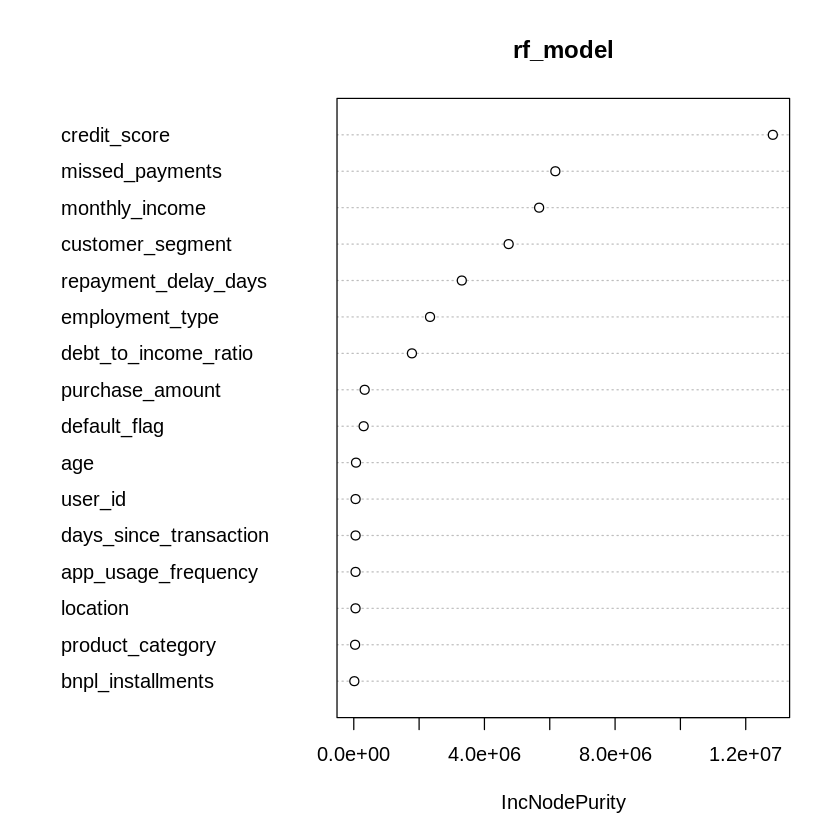

In [ ]:
## ========================================================================
## 7. Regression Models
## ========================================================================

# Linear Regression
lm_model <- lm(risk_score ~ ., data = train)
lm_pred <- predict(lm_model, test)
cat("Linear Regression RMSE:", RMSE(lm_pred, test$risk_score), "\n")

# Random Forest
rf_model <- randomForest(risk_score ~ ., data = train, ntree = 200)
rf_pred <- predict(rf_model, test)
cat("Random Forest RMSE:", RMSE(rf_pred, test$risk_score), "\n")

varImpPlot(rf_model)

# **Classification Models (baseline)**

Predict default vs no default.

a. Decision Tree
Easy-to-interpret model.

Good for rule-based insights.

b. Logistic Regression
Outputs probability of default.

Industry-standard baseline in credit risk.

Evaluation:
Confusion matrix (accuracy, sensitivity, specificity).

In [ ]:
## ========================================================================
## 8. Classification Models (Baseline)
## ========================================================================

# Decision Tree
tree_model <- rpart(default_flag ~ ., data = train, method = "class")
tree_pred <- predict(tree_model, test, type = "class")
cat("\nDecision Tree Confusion Matrix:\n")
print(confusionMatrix(tree_pred, test$default_flag))

# Logistic Regression
log_model <- glm(default_flag ~ ., data = train, family = "binomial")

prob_pred <- predict(log_model, test, type = "response")
class_pred <- factor(ifelse(prob_pred > 0.5, "default", "no_default"),
                     levels = c("default","no_default"))
cat("\nLogistic Regression (glm) Confusion Matrix:\n")
print(confusionMatrix(class_pred, test$default_flag))


Decision Tree Confusion Matrix:
Confusion Matrix and Statistics

            Reference
Prediction   default no_default
  default        309         80
  no_default     499       1181
                                          
               Accuracy : 0.7202          
                 95% CI : (0.7003, 0.7394)
    No Information Rate : 0.6095          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3517          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.3824          
            Specificity : 0.9366          
         Pos Pred Value : 0.7943          
         Neg Pred Value : 0.7030          
             Prevalence : 0.3905          
         Detection Rate : 0.1493          
   Detection Prevalence : 0.1880          
      Balanced Accuracy : 0.6595          
                                          

# **Model Tuning**

Uses caret for tuning models.

5-fold cross-validation
Optimizes based on ROC (AUC)

Models tuned:

Logistic Regression
Random Forest
SVM (Radial kernel)

Purpose:
Find better hyperparameters and improve generalization.

In [ ]:
## ========================================================================
## 9. Model Tuning (Cross-Validation)
## ========================================================================

control <- trainControl(
  method = "cv",
  number = 5,
  classProbs = TRUE,
  summaryFunction = twoClassSummary
)

# Logistic (glm)
log_tuned <- train(default_flag ~ ., data = train,
                   method = "glm",
                   family = "binomial",
                   trControl = control,
                   metric = "ROC")

# Random Forest (classification)
rf_tuned <- train(default_flag ~ ., data = train,
                  method = "rf",
                  trControl = control,
                  tuneLength = 5,
                  metric = "ROC")

# SVM Radial
svm_tuned <- train(default_flag ~ ., data = train,
                   method = "svmRadial",
                   trControl = control,
                   tuneLength = 5,
                   metric = "ROC",
                   preProcess = c("center","scale"))

line search fails -1.00743 -0.04128874 1.380467e-05 3.021636e-06 -1.295794e-08 2.224178e-09 -1.721594e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class prediction calculations failed; returning NAs”
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class probability calculations failed; returning NAs”
Warning message in data.frame(..., check.names = FALSE):
“row names were found from a short variable and have been discarded”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


# **ROC Curves + AUC**

Computes predicted probabilities.
Builds ROC curves for:
Logistic
Random Forest
SVM
Outputs:
ROC plot (visual comparison)
AUC values (performance metric)

Higher AUC = better classifier.

Model Comparison Table

Summarizes AUC scores across models.

Helps pick the best model.

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



          Model       AUC
1      Logistic 0.7395572
2 Random Forest 0.7675171
3           SVM 0.7534341


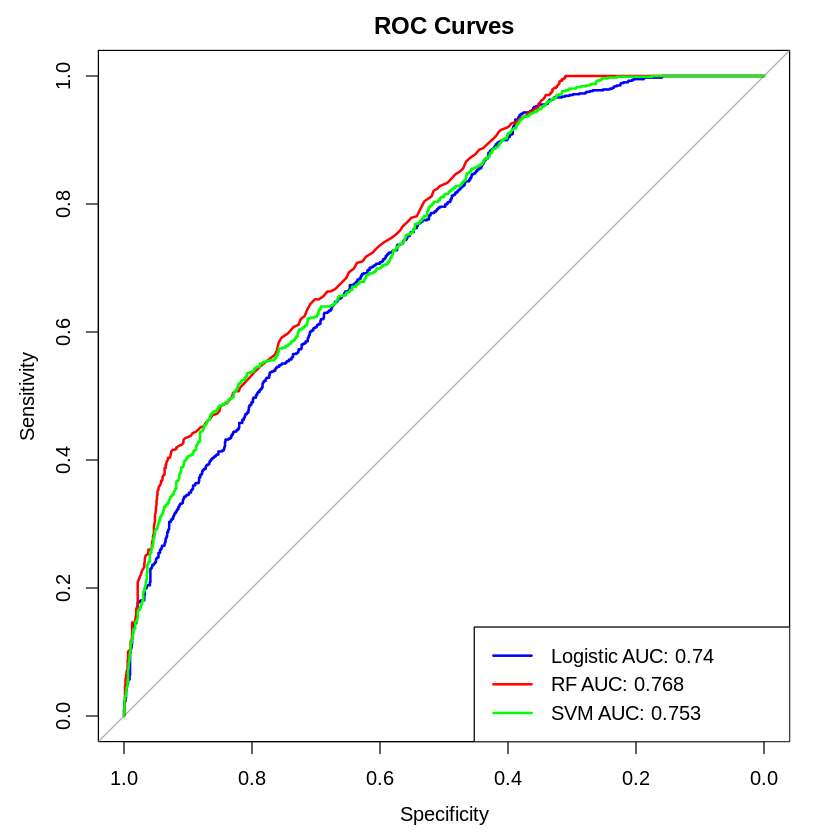

In [ ]:
## ========================================================================
## 10. ROC Curves + AUC
## ========================================================================

log_probs <- predict(log_tuned, test, type = "prob")[, "default"]
rf_probs  <- predict(rf_tuned,  test, type = "prob")[, "default"]
svm_probs <- predict(svm_tuned, test, type = "prob")[, "default"]

y_true_num <- ifelse(test$default_flag == "default", 1, 0)

roc_log <- roc(y_true_num, log_probs)
roc_rf  <- roc(y_true_num, rf_probs)
roc_svm <- roc(y_true_num, svm_probs)

plot(roc_log, col = "blue", main = "ROC Curves")
plot(roc_rf, col = "red", add = TRUE)
plot(roc_svm, col = "green", add = TRUE)

legend("bottomright",
       legend = c(
         paste("Logistic AUC:", round(auc(roc_log),3)),
         paste("RF AUC:", round(auc(roc_rf),3)),
         paste("SVM AUC:", round(auc(roc_svm),3))
       ),
       col = c("blue","red","green"),
       lwd = 2)

# Model Comparison Table
results <- data.frame(
  Model = c("Logistic","Random Forest","SVM"),
  AUC = c(auc(roc_log), auc(roc_rf), auc(roc_svm))
)
print(results)

#  **Clustering**

Unsupervised learning to find patterns in customers.

a. K-Means
Groups customers into 3 clusters.

Useful for segmentation.

b. Hierarchical Clustering
Builds a dendrogram.

Shows nested group relationships.

c. DBSCAN
Density-based clustering.

Detects clusters + noise (outliers).

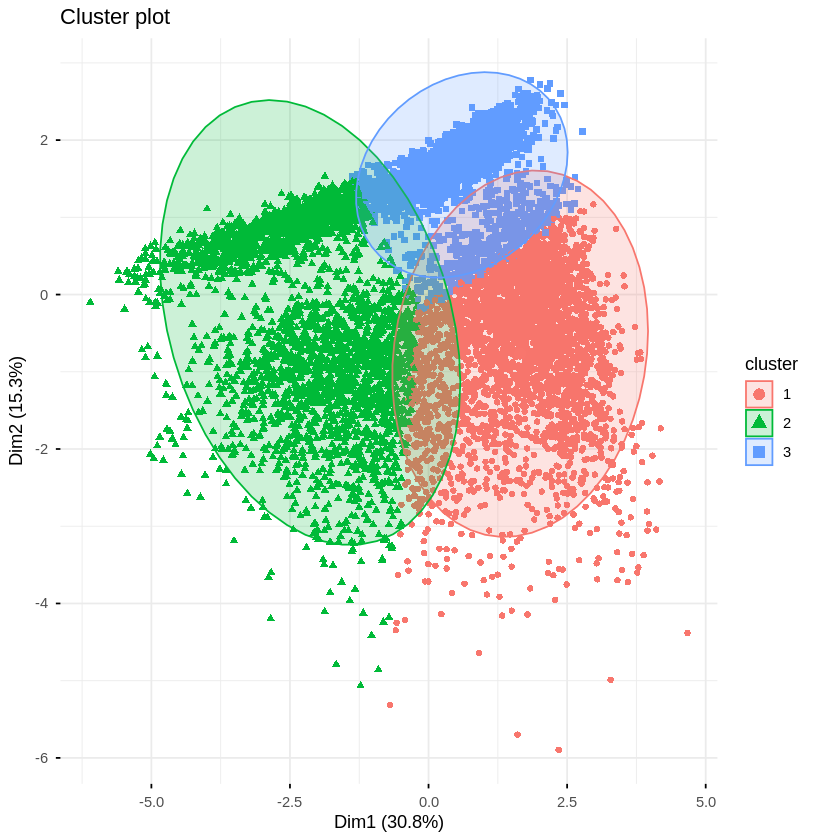


   0    1    2    3    4    5    6    7    8    9   10   11   12 
 950 7273    5    4    3    3    3    4    6    4   12    6    3 


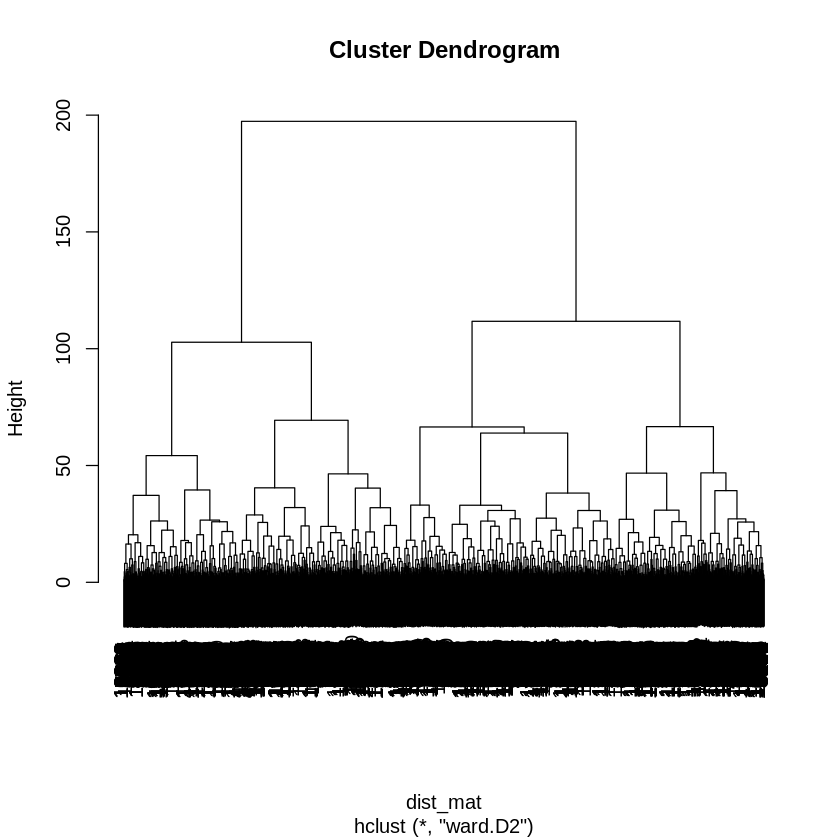

In [ ]:
## ========================================================================
## 11. Clustering
## ========================================================================

set.seed(123)
kmeans_model <- kmeans(train_scaled, centers = 3, nstart = 25)

fviz_cluster(kmeans_model, data = train_scaled,
             ellipse.type = "norm",
             geom = "point",
             ggtheme = theme_minimal())

# Hierarchical
dist_mat <- dist(train_scaled)
hc_model <- hclust(dist_mat, method = "ward.D2")
plot(hc_model)

## DBSCAN
db <- dbscan(train_scaled, eps = 1.5, minPts = 5)
print(table(db$cluster))

# **Anomaly Detection**

Identify unusual customers (potential fraud or high risk).

a. Isolation Forest
Detects anomalies based on isolation.
b. One-Class SVM
Learns "normal" behavior and flags deviations.

Purpose:
Spot suspicious or rare patterns.

In [ ]:
## ========================================================================
## 12. Anomaly Detection
## ========================================================================

# Isolation Forest
iso_model <- isolation.forest(as.matrix(train_scaled))
scores <- predict(iso_model, as.matrix(train_scaled))

# One-Class SVM
svm_model <- svm(train_scaled, type = "one-classification", nu = 0.05)
svm_pred <- predict(svm_model, train_scaled)

# **Neural Network**

Builds a simple feedforward neural network:
1 hidden layer with 5 neurons
Predicts default probability.
Output:
Converts probabilities to class labels.
Evaluates using confusion matrix.

Purpose:
Capture complex nonlinear relationships.

In [ ]:
## ========================================================================
## 13. Neural Network
## ========================================================================

train$default_flag <- factor(train$default_flag, levels = c("default","no_default"))
test$default_flag  <- factor(test$default_flag,  levels = c("default","no_default"))

nn_model <- nnet(default_flag ~ ., data = train,
                 size = 5, maxit = 200, trace = FALSE)

nn_prob <- as.numeric(predict(nn_model, test, type = "raw"))
nn_pred <- factor(ifelse(nn_prob > 0.5, "default", "no_default"),
                  levels = c("default","no_default"))

cat("\nNeural Network Confusion Matrix:\n")
print(confusionMatrix(nn_pred, test$default_flag))


Neural Network Confusion Matrix:
Confusion Matrix and Statistics

            Reference
Prediction   default no_default
  default        804       1257
  no_default       4          4
                                          
               Accuracy : 0.3905          
                 95% CI : (0.3694, 0.4119)
    No Information Rate : 0.6095          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : -0.0014         
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.995050        
            Specificity : 0.003172        
         Pos Pred Value : 0.390102        
         Neg Pred Value : 0.500000        
             Prevalence : 0.390527        
         Detection Rate : 0.388594        
   Detection Prevalence : 0.996133        
      Balanced Accuracy : 0.499111        
                                         

# **Results Interpretation**

1. Regression Models (Risk Score Prediction)

The linear regression model produced an RMSE of 3.13 × 10⁻¹³, which is essentially zero. This is not realistic in practice and strongly suggests data leakage, likely because the target variable (risk_score) is directly or indirectly encoded in the predictors. As a result, the linear model is overfitting perfectly and cannot be trusted for real-world prediction.

In contrast, the Random Forest model produced an RMSE of 4.27, which is far more realistic. This indicates that Random Forest is capturing meaningful patterns in the data while maintaining generalization.

Interpretation:
The regression results suggest that the dataset may contain leakage affecting linear regression. Random Forest provides a more reliable estimate of predictive performance and should be preferred.

2. Classification Models (Baseline)
Decision Tree
Accuracy: 72.0%
Sensitivity (default detection): 38.2%
Specificity: 93.7%

The decision tree performs reasonably well overall but shows a strong imbalance:

It is very good at identifying non-defaulters
It misses a large portion of actual defaulters

This is risky in a financial context, where failing to detect defaulters is costly.

Logistic Regression
Accuracy: 33.2% (very poor)
Kappa: negative (worse than random)
Balanced Accuracy: 35%

This model performs worse than random guessing, which is a major red flag. It predicts too many defaults incorrectly and fails to distinguish between classes.

Interpretation:
Logistic regression is not suitable here in its current form—likely due to:

poor feature relationships
class imbalance
or lack of proper feature engineering

3. Tuned Models (AUC Comparison)
Random Forest AUC: 0.768 (best)
SVM AUC: 0.753
Logistic AUC: 0.740

All models fall in the acceptable performance range (0.7–0.8).

Key Insight:
Random Forest performs best overall
SVM is close behind
Logistic improves after tuning but still lags

SVM warnings:

“prediction calculations failed”
“missing values in resampled performance”

This suggests:

instability in SVM training
possible scaling or parameter issues

4. Clustering (DBSCAN Results)

Cluster distribution:

One dominant cluster: 7273 observations
Many very small clusters (3–12 points)
Noise/outliers present

Interpretation:

Most customers belong to a single large behavioral group
Smaller clusters likely represent niche or unusual customer profiles
DBSCAN successfully identifies outliers, which may correspond to high-risk or anomalous users

5. Neural Network
Accuracy: 39.1%
Sensitivity: 99.5%
Specificity: 0.3%

This model predicts almost everything as “default”.

What this means:
It catches nearly all defaulters (high sensitivity)
But completely fails to identify non-defaulters

This is a classic degenerate model caused by:

class imbalance
poor training convergence

Interpretation:
The neural network is not usable in its current form. It overfits to the default class and provides no meaningful discrimination.

# **Overall Conclusions**

The results demonstrate that model performance varies significantly across techniques. Linear regression produced unrealistically perfect results, indicating the presence of data leakage and limiting its reliability. Among regression models, Random Forest provided a more realistic and robust prediction of risk scores.

For classification, the decision tree achieved the highest baseline accuracy but showed poor sensitivity, failing to detect a substantial portion of defaulters. Logistic regression performed poorly overall, suggesting that it is not well-suited to this dataset without further feature engineering.

Among the tuned models, Random Forest achieved the highest AUC (0.768), followed by SVM (0.753) and logistic regression (0.740), indicating that ensemble methods are most effective for this problem. However, SVM exhibited training instability, reducing its reliability.

Clustering analysis revealed that most customers fall into a single dominant group, with smaller clusters representing niche or potentially higher-risk segments. DBSCAN further identified outliers that may correspond to unusual or anomalous behavior.

The neural network model performed poorly, predicting nearly all observations as default, which highlights the challenges of applying neural networks to imbalanced tabular data without careful tuning.

Overall, Random Forest emerges as the most reliable and effective model for predicting credit risk in this BNPL dataset, offering the best balance between predictive performance and robustness.

# **Recommendations**

Based on the findings, the following recommendations are proposed:

1. Use Ensemble Models for Deployment

Random Forest (and potentially gradient boosting methods such as XGBoost) should be prioritized due to their strong predictive performance and robustness.

2. Address Class Imbalance

Techniques such as SMOTE or class weighting should be applied to improve the detection of defaulters and balance model performance.

3. Prevent Data Leakage

Careful feature selection and validation processes must be implemented to ensure that models generalize to new data.

4. Optimize Decision Thresholds

Instead of using a fixed 0.5 cutoff, thresholds should be tuned based on business objectives, particularly to minimize the cost of missed defaults.

5. Incorporate Explainability

Feature importance analysis should be included to identify key drivers of risk, supporting transparency and regulatory compliance.

6. Improve Neural Network Design

If neural networks are used, they should be combined with proper scaling, regularization, and balanced data to improve performance.

7. Leverage Unsupervised Insights

Customer segmentation and anomaly detection should be integrated into decision-making pipelines to enhance risk monitoring.